Read data from excel file.

In [9]:
import pandas as pd
data = pd.read_excel('/Volumes/SMILeSSD/PacBio/Cy3Cy5/Cy3Cy5_532nm_1000frames_0p1s_12mW_fov1_SNR_analysis.xlsx', sheet_name='Framewise_Spatial_SNR')

------------------------------
数据过滤条件: SNR >= 3
有效数据总数: 8732
均值 (Mean): 17.43
中位数 (Median): 17.51
SNR > 10 的百分比: 90.47%
------------------------------


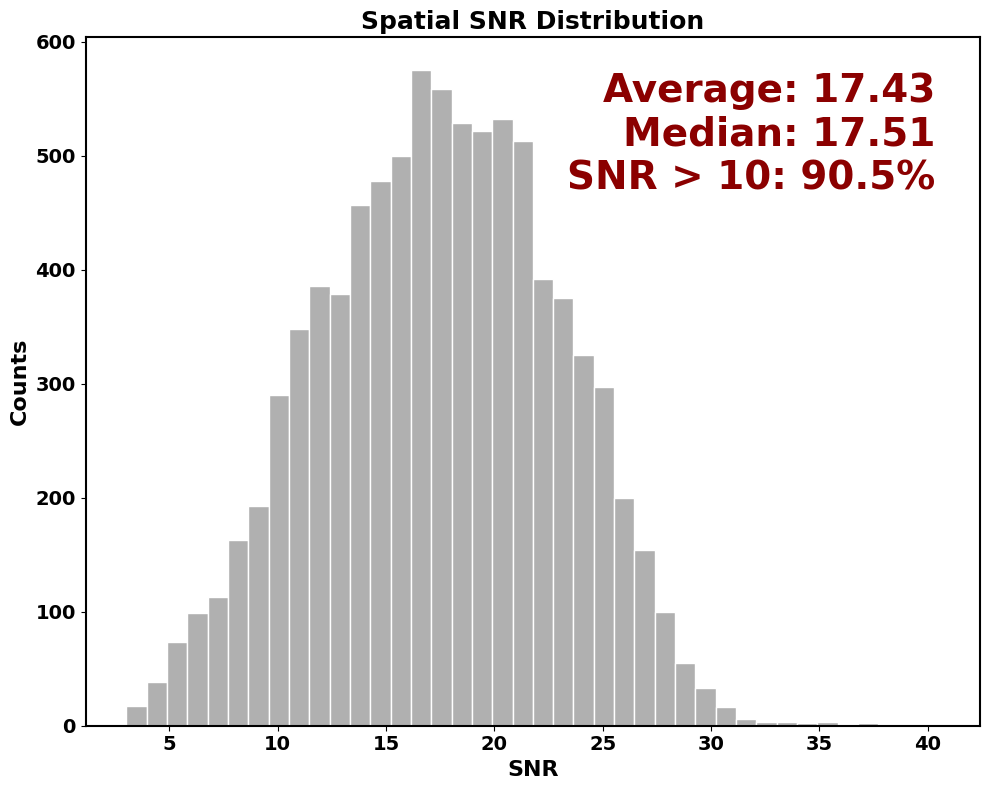

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## 确保列名正确
col_name = 'Spatial_SNR'

# 2. 数据过滤：剔除 SNR < 3 的数据
df = data
filtered_df = df[df[col_name] >= 3].copy()

# 3. 计算统计指标
mean_val = filtered_df[col_name].mean()
median_val = filtered_df[col_name].median()

# 计算 SNR > 10 的百分比
total_count = len(filtered_df)
snr_gt_10_count = len(filtered_df[filtered_df[col_name] > 10])
percentage_gt_10 = (snr_gt_10_count / total_count) * 100

# 打印计算结果
print("-" * 30)
print(f"数据过滤条件: SNR >= 3")
print(f"有效数据总数: {total_count}")
print(f"均值 (Mean): {mean_val:.2f}")
print(f"中位数 (Median): {median_val:.2f}")
print(f"SNR > 10 的百分比: {percentage_gt_10:.2f}%")
print("-" * 30)

# 4. 绘制新的直方图
plt.figure(figsize=(10, 8))

# 绘制直方图，设置颜色和边框（模仿您提供的图表风格）
counts, bins, patches = plt.hist(filtered_df[col_name], bins=40, color='#B0B0B0', edgecolor='white')

# 设置图表标题和坐标轴标签
plt.title('Spatial SNR Distribution', fontsize=18, fontweight='bold')
plt.xlabel('SNR', fontsize=16, fontweight='bold')
plt.ylabel('Counts', fontsize=16, fontweight='bold')

# 调整坐标轴刻度字体大小
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

# 在图表右上角添加统计信息文本
stats_text = (f"Average: {mean_val:.2f}\n"
              f"Median: {median_val:.2f}\n"
              f"SNR > 10: {percentage_gt_10:.1f}%")

# 获取当前坐标轴的范围，用于定位文本
ax = plt.gca()
plt.text(0.95, 0.95, stats_text, 
         transform=ax.transAxes, 
         fontsize=28, 
         fontweight='bold', 
         color='darkred',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none'))

# 调整边框粗细
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# 显示图表
plt.tight_layout()
plt.show()

In [13]:
np.median(col_data)

9.53

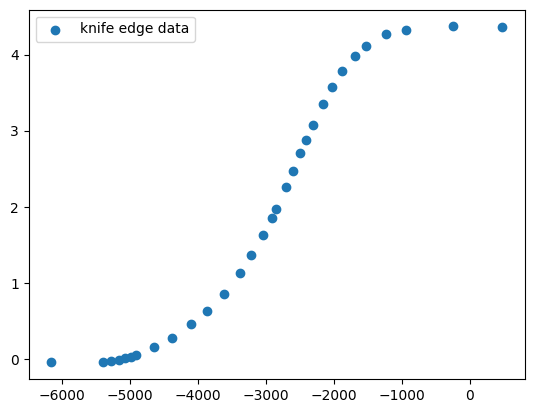

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf

z = list(data['x'])
P = list(data.iloc[:, 1])
P0 = 0.05
P_nobg = [p - P0 for p in P]
plt.scatter(z, P_nobg, label="knife edge data")
plt.legend()
plt.show()

In [37]:
# Define the function to fit
def model(x, P1, P2, P3, bg):
    return P1 / 2 * (1 - erf((- x + P2) * np.sqrt(2) / P3)) + bg
popt, pcov = curve_fit(model, z, P_nobg, p0=[5, -2000, 1500, 0.1])

In [38]:
P1_fit, P2_fit, P3_fit, bg_fit = popt
print(f"Fitted parameters: P1={P1_fit:.3f}(max intensity), P2={P2_fit:.3f}(the distance), w={P3_fit:.3f}(the width), background={bg_fit:.3f}")

Fitted parameters: P1=4.429(max intensity), P2=-2753.616(the distance), w=1825.497(the width), background=0.017


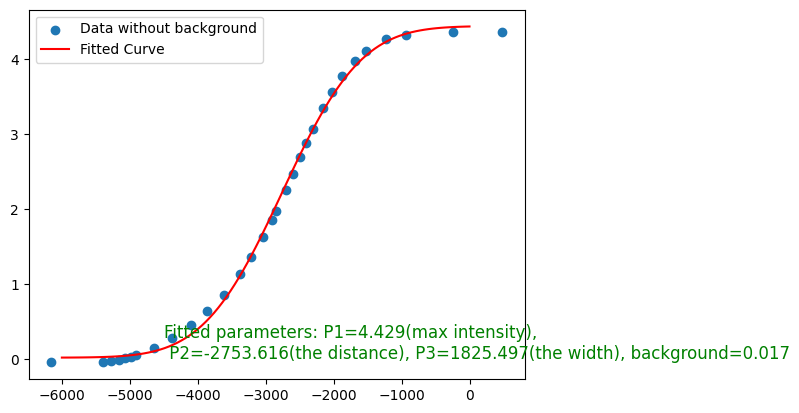

In [39]:
# Generate fitted curve
z_fit = np.linspace(-6000, 0, 100)
P_fit = model(z_fit, *popt)

# Plot results
plt.text(-4500, 0, f"Fitted parameters: P1={P1_fit:.3f}(max intensity),\n P2={P2_fit:.3f}(the distance), P3={P3_fit:.3f}(the width), background={bg_fit:.3f}", fontsize=12, color="green")
plt.scatter(z, P_nobg, label="Data without background")
plt.plot(z_fit, P_fit, color='red', label="Fitted Curve")
plt.legend()
plt.show()